# Agentic segmentation pipeline

Grounding DINO → MedSAM loop reviewed by Gemma 4 E4B (multimodal, cloud).

Before running: set `GEMINI_API_KEY` in Colab Secrets (🔑 left pane).

In [1]:
# === Colab bootstrap ================================================
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os, subprocess, sys
    REPO = '/content/INF8225_Projet'
    if not os.path.isdir(REPO):
        subprocess.check_call(['git', 'clone', '--depth', '1',
            'https://github.com/Azcatchi17/INF8225_Projet.git', REPO])
    if os.getcwd() != REPO:
        os.chdir(REPO)
    if REPO not in sys.path:
        sys.path.insert(0, REPO)
    from colab.setup import setup
    setup()

→ detect GPU
✓ deps already installed, skipping
✓  /content/INF8225_Projet/data already linked
✓  /content/INF8225_Projet/work_dirs already linked
✓  /content/INF8225_Projet/MedSAM/work_dir already linked
✓  /content/INF8225_Projet/grounding_dino_swin-t_pretrain_obj365_goldg_20231122_132602-4ea751ce.pth already linked

Project : /content/INF8225_Projet
Drive   : /content/drive/MyDrive/Projet_Medsam
Device  : Tesla T4
Torch   : 2.4.0+cu121

⚠  numpy was already loaded in this kernel before setup reinstalled it.
   Runtime → Restart session, then run your imports again
   (no need to rerun setup — deps are pinned on disk).


In [2]:
# === Load models (cached across cell reruns) ========================
from pipeline.models import get_dino_model, get_medsam_model, get_gemma_client

_ = get_dino_model()
_ = get_medsam_model()
gemma = get_gemma_client()
print('models ready')

/usr/local/lib/python3.12/dist-packages/mmengine/optim/optimizer/zero_optimizer.py:11: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import \
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loads checkpoint by local backend from path: /content/INF8225_Projet/work_dirs/polyp_config/best_coco_bbox_mAP_epoch_2.pth


/usr/local/lib/python3.12/dist-packages/mmengine/runner/checkpoint.py:347: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(filename, map_location=map_l

models ready


In [3]:
# === Gemma smoke test (text + multimodal round-trip) ================
import json
from pathlib import Path
from pipeline import config, medsam
from pipeline.gemma import smoke_test

sample_img = next(config.KVASIR_IMAGES.glob('*.jpg'))
image_np = medsam.load_image(str(sample_img))
print(json.dumps(smoke_test(gemma, image_np), indent=2))

{
  "refine": {
    "search_text": "polyp",
    "synonyms": [
      "lesion",
      "tumor",
      "growth"
    ]
  },
  "analyze": {
    "action": "replace_box",
    "params": {
      "box_2d": [
        390,
        440,
        680,
        760
      ]
    },
    "rationale": "The current mask is completely misplaced and does not cover the target polyp. A new box is needed to enclose the polyp."
  }
}


[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['polyp']


/usr/local/lib/python3.12/dist-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py:116: RuntimeWarning: Grounding DINO CUDA ops do not support bfloat16 in this environment; retrying in float32.
  return func(*args, **kwargs)
[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['polyp']


/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'


run_id         : 2026-04-17T05-19-47-327
refined prompt : polyp
stop reason    : max_iter
  iter 0: action=—              dice=0.963009069891517 area_pct=0.104
  iter 1: action=add_positive   dice=0.28336502135855207 area_pct=0.018
  iter 2: action=replace_box    dice=0.963009069891517 area_pct=0.104
  iter 3: action=add_positive   dice=0.28336502135855207 area_pct=0.018
  iter 4: action=replace_box    dice=0.963009069891517 area_pct=0.104


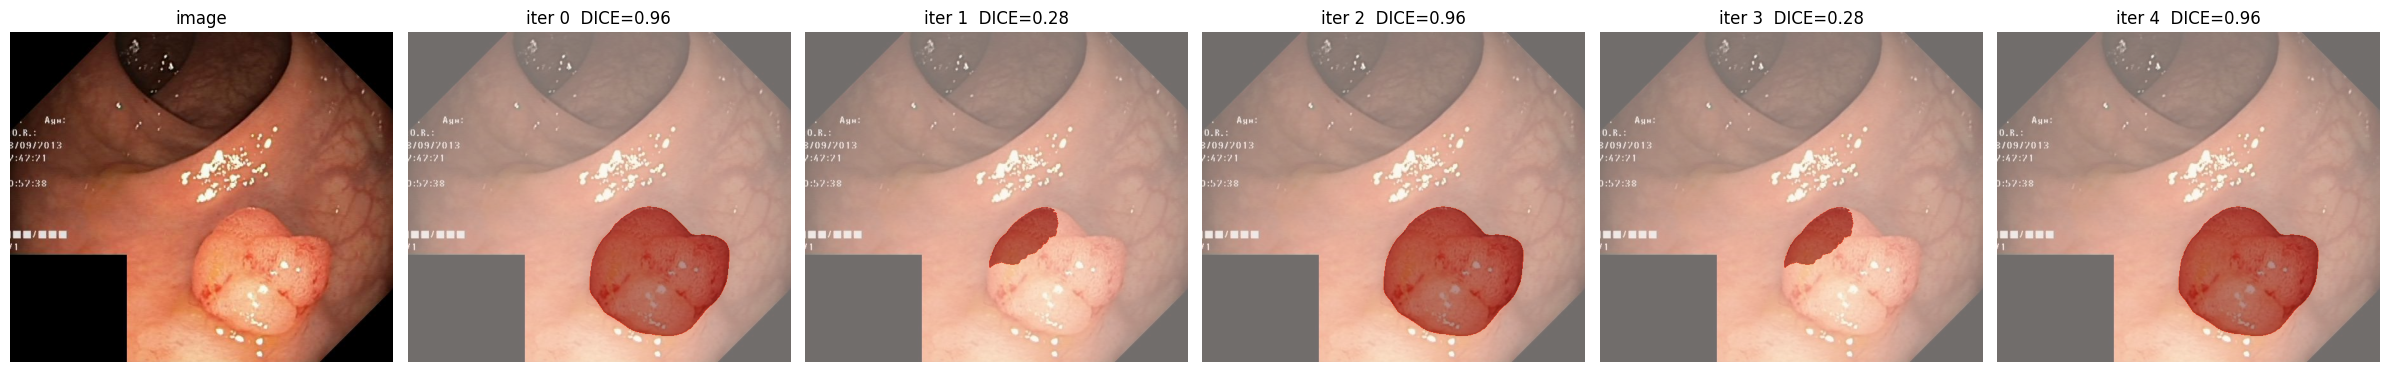

In [4]:
# === Single-image demo ==============================================
import matplotlib.pyplot as plt
import numpy as np
from skimage import io
from pipeline import config
from pipeline.agent import run_agent

demo_file = next(config.KVASIR_IMAGES.glob('*.jpg'))
gt_path = config.KVASIR_MASKS / demo_file.name
gt = None
if gt_path.exists():
    m = io.imread(gt_path)
    gt = (m[..., 0] if m.ndim == 3 else m) > 0
    gt = gt.astype(np.uint8)

state = run_agent(str(demo_file), 'find the polyp', gt_mask=gt)
print(f'run_id         : {state.run_id}')
print(f'refined prompt : {state.refined_prompt}')
print(f'stop reason    : {state.stop_reason}')
for it in state.iterations:
    act = it.gemma_action.action if it.gemma_action else '—'
    print(f'  iter {it.iteration}: action={act:<14} '
          f'dice={it.dice_vs_gt} area_pct={it.metrics.area_pct:.3f}')

# Plot original + each iteration's mask overlay
n = 1 + len(state.iterations)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
axes[0].imshow(state.image_np); axes[0].set_title('image'); axes[0].axis('off')
for i, it in enumerate(state.iterations, start=1):
    axes[i].imshow(state.image_np)
    axes[i].imshow(it.mask, alpha=0.45, cmap='Reds')
    axes[i].set_title(f'iter {it.iteration}'
                      + (f'  DICE={it.dice_vs_gt:.2f}' if it.dice_vs_gt is not None else ''))
    axes[i].axis('off')
plt.tight_layout(); plt.show()

In [5]:
# === Batch evaluation on test.json ==================================
from pipeline.eval import run_batch

df = run_batch(n=20)  # set n=None for the full test set
df.describe()[['first_iter_dice', 'final_dice', 'n_iterations']]

agentic:   0%|          | 0/20 [00:00<?, ?it/s][nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['polyp']


/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'
agentic:   5%|▌         | 1/20 [00:33<10:27, 33.04s/it][nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['polyp']


/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'
agentic:  10%|█         | 2/20 [00:40<05:25, 18.09s/it][nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


...

noun_phrases: ['polyp']


/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'
agentic:  95%|█████████▌| 19/20 [05:33<00:17, 17.43s/it][nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['polyp']


/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'
agentic: 100%|██████████| 20/20 [05:45<00:00, 17.29s/it]


,first_iter_dice,final_dice,n_iterations
count,20.000000,20.000000,20.000000
mean,0.822913,0.740933,3.200000
std,0.250432,0.299879,1.472556
min,0.200867,0.038896,1.000000
25%,0.858237,0.537315,2.000000
50%,0.937374,0.915552,2.500000
75%,0.967436,0.937271,5.000000
max,0.982446,0.978488,5.000000


In [6]:
# === One-shot vs agentic comparison =================================
from pipeline.eval import compare_oneshot_vs_agentic

cmp_df = compare_oneshot_vs_agentic(n=50)
print(cmp_df[['one_shot_dice', 'agentic_dice', 'dice_delta']].describe())

compare:   0%|          | 0/50 [00:00<?, ?it/s][nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['polyp']


/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'
[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['polyp']


/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'
compare:   2%|▏         | 1/50 [00:10<08:12, 10.04s/it][nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


...

noun_phrases: ['polyp']


/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'
[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['polyp']


/usr/local/lib/python3.12/dist-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'
compare: 100%|██████████| 50/50 [15:41<00:00, 18.84s/it]


saved /content/INF8225_Projet/data/agent_results/comparison_2026-04-17T05-26-01.csv
saved /content/INF8225_Projet/data/agent_results/comparison_2026-04-17T05-26-01.png
       one_shot_dice  agentic_dice  dice_delta
count      50.000000     50.000000   50.000000
mean        0.865914      0.782540   -0.083374
std         0.174898      0.255985    0.202577
min         0.200867      0.048463   -0.759744
25%         0.880883      0.667178   -0.007586
50%         0.939429      0.914329    0.000000
75%         0.959905      0.952281    0.000000
max         0.982446      0.982385    0.133771
